### Setup

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd
from scipy.stats import poisson


In [2]:
def quick_plot(func,x = None,y = None,yerr = None,label = None , title = None , x_title = None , 
               y_title = None, p0 = None,log = '.'):
    """
    Uses Scipy curve_fit to automatically create comparison plot and residual plot.
    MUST define func() before using function!
    Can take inf amount of function arguments!
    Stores Scipy Perr and popt
    """

    popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)

    perr = np.sqrt(np.diag(pcov))
    
    y_fit = func(x,*popt)
    
    print(*popt)
    print(*perr)

    plt.errorbar (x, y,fmt = 'o',yerr = yerr,label = label )
    plt.plot(x,y_fit)
    plt.title(title)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.grid()
    plt.show()


    resid = y - y_fit

    plt.errorbar(x,resid,yerr = yerr, fmt = 'o',label = label)
    plt.axhline(y = 0, color = 'black', linestyle = '--')
    plt.grid()
    plt.legend()
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()


### 7.4.1

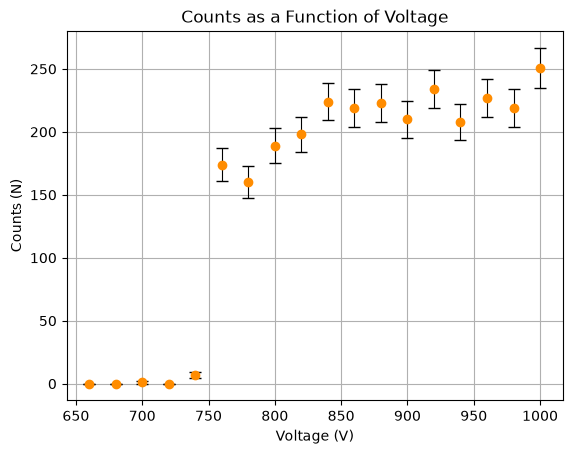

/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_49962/4146986370.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


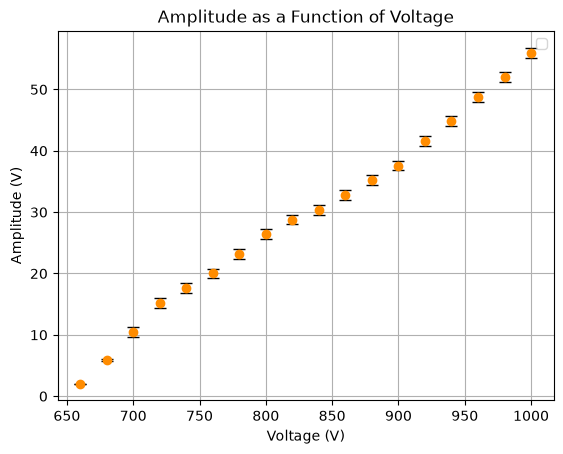

,Tube Voltage,Amp_1,Amp_2,unc_amp,Count,Time
0,660,0.0,2.04,0.00,0,5
1,680,6.0,5.92,0.16,0,5
2,700,11.2,10.40,0.80,1,5
3,720,16.0,15.20,0.80,0,5
4,740,17.6,17.60,0.80,7,5
5,760,20.8,20.00,0.80,174,5
6,780,24.0,23.20,0.80,160,5
7,800,27.2,26.40,0.80,189,5
8,820,28.0,28.80,0.80,198,5
9,840,30.4,30.40,0.80,224,5


In [130]:
df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.4.1_ Configuration.csv')

counts = df.iloc[:,4]
voltage = df.iloc[:,0]
amplitude = df.iloc[:,2]
unc_amp = df.iloc[:,3]

plt.errorbar(voltage,counts,yerr = np.sqrt(df.iloc[:,4]),
             fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4, label = 'counts')
plt.title('Counts as a Function of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Counts (N)')
plt.grid(True)
plt.show()

plt.errorbar(voltage,amplitude,yerr = unc_amp,fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4)
plt.legend()
plt.title('Amplitude as a Function of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Amplitude (V)')
plt.grid(True)
plt.show()

df

### 7.4.1

### 7.4.2

### 7.4.3 POSSION DIST

χ² = 10.79


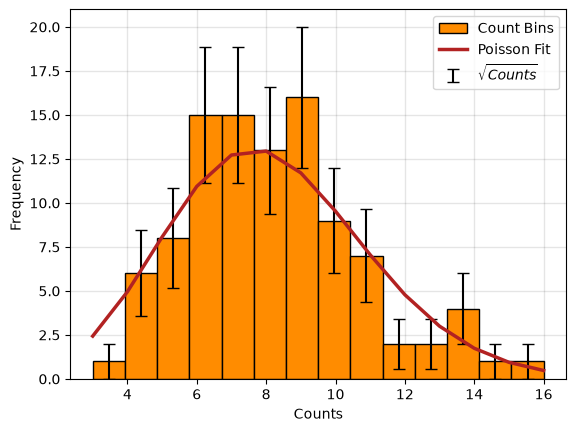

In [3]:
from scipy.special import factorial
df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.4.3_ Poisson.csv')

counts = df.iloc[:,1]
trials = df.iloc[:,0]
total_trials = len(counts)

sigma = np.sqrt(counts)

mean = np.mean(counts)

pmf_values = poisson.pmf(14,mean)



x_range = np.arange(int(counts.min()), int(counts.max()) + 1)




t = np.arange(0,100,1)

freq, bins, patches = plt.hist(x = counts, bins = 14, color = 'darkorange',edgecolor = 'black', label = "Count Bins")

bincenters = (bins[:-1] + bins[1:]) *0.5

bin_width = bins[1] - bins[0]

scaled_pmf = poisson.pmf(x_range, mean) * total_trials * bin_width


errors = np.sqrt(freq)


chi_2 = np.sum(((scaled_pmf - freq)**2)/errors**2)

print(f"χ² = {chi_2:.2f}")

plt.errorbar(bincenters, freq, yerr=errors, fmt='none', ecolor='black', capsize=4, elinewidth=1.5, label = r'$\sqrt{Counts}$')
plt.plot(x_range, scaled_pmf, color='firebrick', linewidth=2.5, label='Poisson Fit')

plt.legend()

plt.grid(True, color='black', linewidth=1,alpha = 0.1)
plt.gca().set_axisbelow(True)

plt.ylabel('Frequency')
plt.xlabel('Counts')
plt.axis(True)
plt.show()

### 7.4.4 Dead Time

### 7.4.5 Lead Absorption

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Load Data
df = pd.read_csv('/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.5 Lead Absorption.csv')

# 2. Extract Background Parameters (Using index positions from your script)
back_count = df.iloc[1,2]
back_time = df.iloc[1,3]
back_rate = df.iloc[1,4] # Background Rate (counts/sec)
sigma_back = np.sqrt(back_rate / back_time)

# 3. Extract Measurement Arrays
thick = df.iloc[:,0]      # Thickness (mm)
counts = df.iloc[:,2]     # Raw Counts N (Assumed column 2 based on your background index)
time = df.iloc[:,3]       # Time t (seconds)
meas_rate = df.iloc[:,4]  # Measured Gross Rate (counts/sec)

# 4. Correct for Background
net_rate = meas_rate - back_rate
countrate = np.log(net_rate)

# 5. Propagate Errors Correctly
# Error in net rate: sigma_net^2 = sigma_gross^2 + sigma_back^2
sigma_gross = np.sqrt(meas_rate / time)
sigma_net = np.sqrt(sigma_gross**2 + sigma_back**2)

# Error in ln(net_rate): sigma = sigma_net / net_rate
sigma = sigma_net / net_rate

# 6. Linear Fitting Function
def func(thick, m, b):
    return (m * thick + b)

popt, pcov = curve_fit(func, thick, countrate, sigma=sigma, absolute_sigma=True)
slope, intercept = popt
slope_sig, intercept_sig = np.sqrt(np.diag(pcov))

# 7. Goodness of Fit (Chi-Squared)
y_fit = func(thick, *popt)
resid = countrate - y_fit
chi2 = np.sum((resid / sigma) ** 2)
dof = len(thick) - len(popt)
reduced_chi2 = chi2 / dof

# 8. Print Results
print(f"Slope (μ): {slope:.4f} ± {slope_sig:.4f} mm^-1")
print(f"Intercept: {intercept:.4f} ± {intercept_sig:.4f}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi2:.4f}")

# 9. Plotting
plt.errorbar(thick, countrate, yerr=sigma, fmt='o', color='darkorange', 
             ecolor='black', elinewidth=0.8, capsize=4, label='Net Counts (ln)')
plt.plot(thick, y_fit, color='royalblue', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')

plt.title('Log of Net Count Rate as a Function of Lead Thickness')
plt.xlabel('Lead Thickness (mm)')
plt.ylabel('ln(Net Count Rate) (N/s)')
plt.grid(True)
plt.legend()
plt.show()


ValueError: array must not contain infs or NaNs

Slope (μ): 1.0000 ± inf mm^-1
Intercept: 1.0000 ± inf


/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_61460/617459860.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func,thick,countrate,sigma = sigma,absolute_sigma = True)


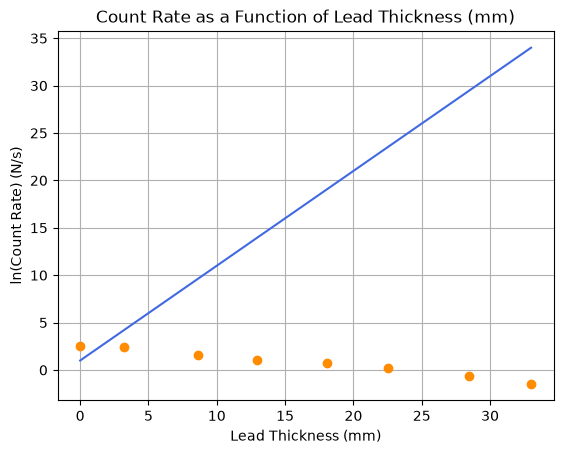

0.0


In [ ]:
df = pd.read_csv('/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.5 Lead Absorption.csv')
df_back = pd.read_csv('/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - Daily Background Count.csv')

back_count = df.iloc[1,2]
back_time = df.iloc[1,3]
back_rate = df.iloc[1,4]

sigma_back = np.sqrt(back_rate/back_time)


thick = df.iloc[:,0]
countr = df.iloc[:,3]
countrate = np.log(df.iloc[:,3])
sigma = 1/(np.sqrt(np.abs(countr)))

sigma = np.square(sigma**2 + sigma_back**2)



def func(thick,m,b):
    return (m*thick + b)

popt, pcov = curve_fit(func,thick,countrate,sigma = sigma,absolute_sigma = True)

y_fit = func(thick,*popt)


slope, intercept = popt
slope_sig, intercept_sig = np.sqrt(np.diag(pcov))

resid = y_fit - countrate

print(f"Slope (μ): {slope:.4f} ± {slope_sig:.4f} mm^-1")
print(f"Intercept: {intercept:.4f} ± {intercept_sig:.4f}")


plt.plot(thick, y_fit, color='royalblue', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')

plt.errorbar(thick,countrate,yerr = sigma,
             fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4, label = 'counts')
plt.title('Count Rate as a Function of Lead Thickness (mm)')
plt.xlabel('Lead Thickness (mm)')
plt.ylabel('ln(Count Rate) (N/s)')
plt.grid(True)
plt.show()


chi2 = np.sum((resid / sigma) ** 2)
dof = len(thick) - len(popt)
chi2 = chi2 

print(chi2/dof)
